# DATA COLLECTION

In [ ]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"pooraniayswariyaps","key":"19bed4598ff7aab45cf59c4763d0f7f6"}'}

In [ ]:
import os
import shutil

os.makedirs("/root/.kaggle", exist_ok=True)
shutil.move("kaggle.json", "/root/.kaggle/kaggle.json")

os.chmod("/root/.kaggle/kaggle.json", 600)

print("Kaggle.json configured successfully!")

Kaggle.json configured successfully!


In [ ]:
!pip install kaggle


In [ ]:
!kaggle datasets download -d brjapon/cwru-bearing-datasets

Dataset URL: https://www.kaggle.com/datasets/brjapon/cwru-bearing-datasets
License(s): CC-BY-SA-4.0
  0% 0.00/40.4M [00:00<?, ?B/s]
100% 40.4M/40.4M [00:00<00:00, 1.50GB/s]


In [ ]:
import zipfile

zip_path = "cwru-bearing-datasets.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("CWRU_Dataset")

print("Dataset extracted successfully into CWRU_Dataset folder!")


Dataset extracted successfully into CWRU_Dataset folder!


In [ ]:
import os

for root, dirs, files in os.walk("CWRU_Dataset"):
    for file in files:
        if file.endswith(".mat") or file.endswith(".npz") or file.endswith(".csv"):
            print(os.path.join(root, file))


CWRU_Dataset/CWRU_48k_load_1_CNN_data.npz
CWRU_Dataset/feature_time_48k_2048_load_1.csv
CWRU_Dataset/raw/IR014_1_175.mat
CWRU_Dataset/raw/OR007_6_1_136.mat
CWRU_Dataset/raw/IR007_1_110.mat
CWRU_Dataset/raw/OR014_6_1_202.mat
CWRU_Dataset/raw/OR021_6_1_239.mat
CWRU_Dataset/raw/B007_1_123.mat
CWRU_Dataset/raw/B014_1_190.mat
CWRU_Dataset/raw/Time_Normal_1_098.mat
CWRU_Dataset/raw/B021_1_227.mat
CWRU_Dataset/raw/IR021_1_214.mat


# DATA PREPARATION

**Import Libraries**

In [ ]:
import os
import glob
import numpy as np
import scipy.io as sio
import pandas as pd

from scipy.stats import skew, kurtosis

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout


**Loading all .mat files**

In [ ]:
DATA_PATH = "CWRU_Dataset/raw/*.mat"
mat_files = glob.glob(DATA_PATH)

print("Total .mat files found:", len(mat_files))
print(*mat_files, sep="\n")

Total .mat files found: 10
CWRU_Dataset/raw/IR014_1_175.mat
CWRU_Dataset/raw/OR007_6_1_136.mat
CWRU_Dataset/raw/IR007_1_110.mat
CWRU_Dataset/raw/OR014_6_1_202.mat
CWRU_Dataset/raw/OR021_6_1_239.mat
CWRU_Dataset/raw/B007_1_123.mat
CWRU_Dataset/raw/B014_1_190.mat
CWRU_Dataset/raw/Time_Normal_1_098.mat
CWRU_Dataset/raw/B021_1_227.mat
CWRU_Dataset/raw/IR021_1_214.mat


**Function to Extract Signal from .mat files**

In [ ]:
def extract_signal_from_mat(file_path):
    mat_data = sio.loadmat(file_path)

    signal_key = None
    for key in mat_data.keys():
        if "DE_time" in key:
            signal_key = key
            break

    if signal_key is None:
        raise ValueError(f"DE_time signal not found in {file_path}")

    signal = mat_data[signal_key].flatten()
    return signal


**Function to Extract Label from Filename**

In [ ]:
def get_label_from_filename(file_path):
    filename = os.path.basename(file_path)

    if "Normal" in filename:
        return "Normal"
    elif filename.startswith("IR"):
        return "IR"
    elif filename.startswith("OR"):
        return "OR"
    elif filename.startswith("B"):
        return "B"
    else:
        return "Unknown"


**Segment the Signal into Equal Windows**

In [ ]:
def segment_signal(signal, segment_size=2048):
    segments = []
    for i in range(0, len(signal) - segment_size, segment_size):
        segments.append(signal[i:i+segment_size])
    return np.array(segments)


**Extract statistical features from each segment**

In [ ]:
def extract_features(segment):
    features = []

    features.append(np.mean(segment))              # Mean
    features.append(np.std(segment))               # Std Dev
    features.append(np.max(segment))               # Max
    features.append(np.min(segment))               # Min
    features.append(np.sqrt(np.mean(segment**2)))  # RMS
    features.append(np.ptp(segment))               # Peak-to-Peak
    features.append(skew(segment))                 # Skewness
    features.append(kurtosis(segment))             # Kurtosis

    return features


**Build Dataset from ALL .mat Files**

In [ ]:
X = [] # Features
y = [] # Labels

SEGMENT_SIZE = 2048

for file in mat_files:
    signal = extract_signal_from_mat(file)
    label = get_label_from_filename(file)

    if label == "Unknown":
        continue

    segments = segment_signal(signal, SEGMENT_SIZE)

    for seg in segments:
        feat = extract_features(seg)
        X.append(feat)
        y.append(label)

X = np.array(X)
y = np.array(y)

print("Final dataset shape (X):", X.shape)
print("Final labels shape (y):", y.shape)
print("Classes:", np.unique(y))


Final dataset shape (X): (2369, 8)
Final labels shape (y): (2369,)
Classes: ['B' 'IR' 'Normal' 'OR']


**Encode Labels + Feature Scaling**

In [ ]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Encoded classes:", label_encoder.classes_)


Encoded classes: ['B' 'IR' 'Normal' 'OR']


**Train-Test Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)


Training set: (1895, 8)
Testing set: (474, 8)


# MODEL BUILDING - MLP

**Build MLP Model**

In [ ]:
from tensorflow.keras.optimizers import Adam

In [ ]:
mlp_model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2),

    Dense(128, activation='relu'),
    Dropout(0.2),

    Dense(len(np.unique(y_encoded)), activation='softmax')
])

mlp_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

mlp_model.summary()


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_46 (Dense)                │ (None, 256)            │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,716 (139.52 KB)

 Trainable params: 35,716 (139.52 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)


In [ ]:
history = mlp_model.fit(X_train, y_train,
                        validation_data=(X_test, y_test),
                        epochs=30,
                        batch_size=32,
                        callbacks=[early_stop])


Epoch 1/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6248 - loss: 0.9407 - val_accuracy: 0.8502 - val_loss: 0.4324
Epoch 2/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8316 - loss: 0.4449 - val_accuracy: 0.8565 - val_loss: 0.3405
Epoch 3/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8523 - loss: 0.3552 - val_accuracy: 0.8692 - val_loss: 0.2890
Epoch 4/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8693 - loss: 0.3126 - val_accuracy: 0.8797 - val_loss: 0.2620
Epoch 5/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8710 - loss: 0.3144 - val_accuracy: 0.8776 - val_loss: 0.2454
Epoch 6/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8733 - loss: 0.2911 - val_accuracy: 0.9030 - val_loss: 0.2316
Epoch 7/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8875 - loss: 0.2553 - val_accuracy: 0.9051 - val_loss: 0.2160
Epoch 8/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8881 - loss: 0.2504 - val_accuracy: 0.9030 - val_loss:

In [ ]:
y_pred_probs = mlp_model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(
    y_test, y_pred,
    target_names=label_encoder.classes_
))

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Accuracy: 0.9556962025316456

Classification Report:
               precision    recall  f1-score   support

           B       0.92      0.93      0.93       142
          IR       0.98      1.00      0.99       142
      Normal       0.96      1.00      0.98        47
          OR       0.96      0.92      0.94       143

    accuracy                           0.96       474
   macro avg       0.96      0.96      0.96       474
weighted avg       0.96      0.96      0.96       474



15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


<Figure size 700x600 with 0 Axes>

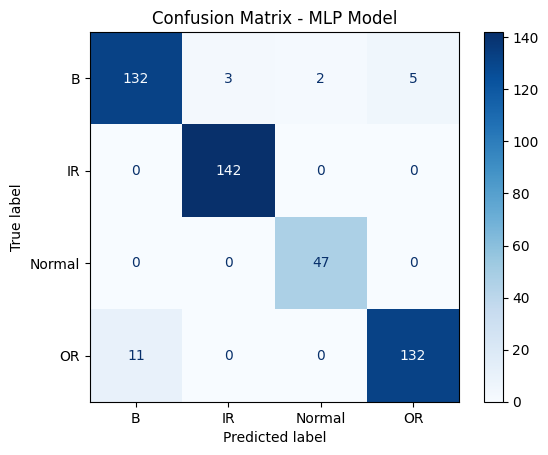

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predictions
y_pred_probs = mlp_model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)

plt.figure(figsize=(7,6))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - MLP Model")
plt.show()


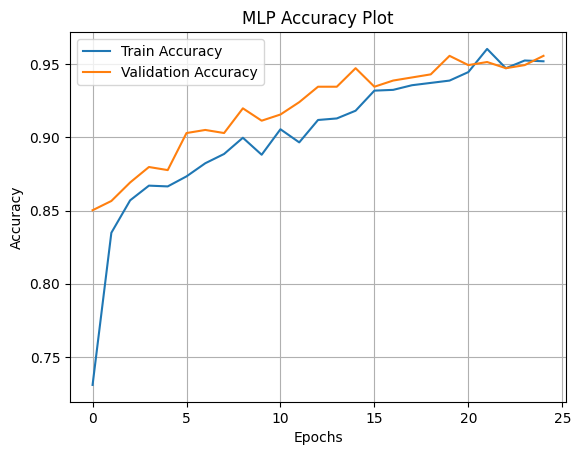

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("MLP Accuracy Plot")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import joblib

mlp_model.save("MLP_CWRU_model.keras")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(label_encoder, "label_encoder.pkl")

print("Model saved successfully in .keras format!")



Model saved successfully in .keras format!
